In [1]:
# Importa la biblioteca matemática
import numpy as np
# Se usa para repmat
import numpy.matlib
# Importa la biblioteca de gráficos
import matplotlib.pyplot as plt
# Importa la biblioteca math
import math

In [2]:
# Define la función Unidad Lineal Rectificada (ReLU)
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

# Define una red neuronal poco profunda
def shallow_nn(x, beta_0, omega_0, beta_1, omega_1):
    # Asegura que los datos de entrada sean un arreglo de tamaño (1 x n_data)
    n_data = x.size
    x = np.reshape(x,(1,n_data))

    # Ejecuta la red para TODAS las entradas x a la vez para poder graficar
    h1 = ReLU(np.matmul(beta_0,np.ones((1,n_data))) + np.matmul(omega_0,x))
    model_out = np.matmul(beta_1,np.ones((1,n_data))) + np.matmul(omega_1,h1)
    return model_out

In [3]:
# Obtiene los parámetros del modelo; esta función permite restablecerlos fácilmente
def get_parameters():
  # Crea una red que se ajusta aproximadamente a los datos
  beta_0 = np.zeros((3,1));  # antes theta_x0
  omega_0 = np.zeros((3,1)); # antes theta_x1
  beta_1 = np.zeros((3,1));  # NOTA: ahora hay tres salidas, una por clase, y por tanto tres sesgos de salida
  omega_1 = np.zeros((3,3)); # NOTA: ahora hay tres salidas y nueve pesos que conectan 3 unidades ocultas con 3 salidas

  beta_0[0,0] = 0.3; beta_0[1,0] = -1.0; beta_0[2,0] = -0.5
  omega_0[0,0] = -1.0; omega_0[1,0] = 1.8; omega_0[2,0] = 0.65
  beta_1[0,0] = 2.0; beta_1[1,0] = -2; beta_1[2,0] = 0.0
  omega_1[0,0] = -24.0; omega_1[0,1] = -8.0; omega_1[0,2] = 50.0
  omega_1[1,0] = -2.0; omega_1[1,1] = 8.0; omega_1[1,2] = -30.0
  omega_1[2,0] = 16.0; omega_1[2,1] = -8.0; omega_1[2,2] =-8

  return beta_0, omega_0, beta_1, omega_1

In [4]:
# Función auxiliar para graficar los datos
def plot_multiclass_classification(x_model, out_model, lambda_model, x_data = None, y_data = None, title= None):
  # Asegura que los datos del modelo sean arreglos unidimensionales
  n_data = len(x_model)
  n_class = 3
  x_model = np.squeeze(x_model)
  out_model = np.reshape(out_model, (n_class,n_data))
  lambda_model = np.reshape(lambda_model, (n_class,n_data))

  fig, ax = plt.subplots(1,2)
  fig.set_size_inches(7.0, 3.5)
  fig.tight_layout(pad=3.0)
  ax[0].plot(x_model,out_model[0,:],'r-')
  ax[0].plot(x_model,out_model[1,:],'g-')
  ax[0].plot(x_model,out_model[2,:],'b-')
  ax[0].set_xlabel('Entrada, $x$'); ax[0].set_ylabel('Salidas del modelo')
  ax[0].set_xlim([0,1]);ax[0].set_ylim([-4,4])
  if title is not None:
    ax[0].set_title(title)
  ax[1].plot(x_model,lambda_model[0,:],'r-')
  ax[1].plot(x_model,lambda_model[1,:],'g-')
  ax[1].plot(x_model,lambda_model[2,:],'b-')
  ax[1].set_xlabel('Entrada, $x$'); ax[1].set_ylabel('$lambda$ o p(y=k|x)')
  ax[1].set_xlim([0,1]);ax[1].set_ylim([-0.1,1.05])
  if title is not None:
    ax[1].set_title(title)
  if x_data is not None:
    for i in range(len(x_data)):
      if y_data[i] ==0:
        ax[1].plot(x_data[i],-0.05, 'r.')
      if y_data[i] ==1:
        ax[1].plot(x_data[i],-0.05, 'g.')
      if y_data[i] ==2:
        ax[1].plot(x_data[i],-0.05, 'b.')
  plt.show()

# Clasificación multiclase

En la clasificación multiclase, la red debe predecir la probabilidad de $K$ clases mediante $K$ salidas. Estas probabilidades deben ser no negativas y sumar uno, aunque las salidas de la red pueden tomar valores arbitrarios. Por ello, aplicamos una función softmax que transforma $K$ valores arbitrarios en $K$ valores no negativos cuya suma es uno.

In [5]:
# Función softmax que transforma valores arbitrarios en valores positivos cuya suma es uno
def softmax(model_out):
  # Esta operación debe realizarse por separado para cada columna de la entrada
  # Calcula las exponenciales de todos los elementos
  # TODO: calcula la función softmax
  # Reemplaza este código provisional

  # Calcula la exponencial de las salidas del modelo
  exp_model_out = np.exp(model_out)
  # Calcula la suma de las exponenciales
  sum_exp_model_out = np.sum(exp_model_out, axis=0)
  # Normaliza las exponenciales; np.matlib.repmat puede ser útil aquí
  softmax_model_out = exp_model_out / sum_exp_model_out

  return softmax_model_out

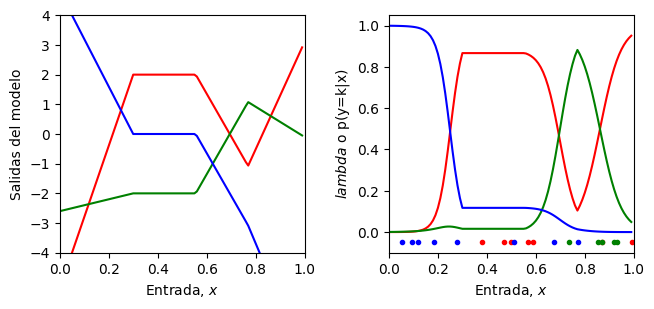

In [6]:

# Crea algunos datos de entrenamiento unidimensionales
x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([2,0,1,2,1,0,\
                    0,2,2,0,2,0,\
                    2,0,1,2,1,2, \
                    1,0])

# Obtiene los parámetros del modelo
beta_0, omega_0, beta_1, omega_1 = get_parameters()

# Define un rango de valores de entrada
x_model = np.arange(0,1,0.01)
# Ejecuta el modelo para obtener y graficar sus valores
model_out= shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
lambda_model = softmax(model_out)
plot_multiclass_classification(x_model, model_out, lambda_model, x_train, y_train)


A la izquierda se muestran las salidas del modelo y a la derecha, las salidas después de aplicar softmax. Ahora están en el rango [0,1] y representan las probabilidades de y=0 (rojo), 1 (verde) y 2 (azul). Los puntos inferiores son los datos de entrenamiento con los mismos colores. Cada curva debe ser alta donde aparecen puntos de su color. Calcularemos la likelihood y la likelihood logarítmica negativa.

In [7]:
# Devuelve la probabilidad de la clase observada y según una distribución categórica
# Toma el valor de la fila k del parámetro lambda donde y=k
def categorical_distribution(y, lambda_param):
    return np.array([lambda_param[row, i] for i, row in enumerate (y)])

In [8]:
# Tres ejemplos
print(categorical_distribution(np.array([[0]]),np.array([[0.2],[0.5],[0.3]])))
print(categorical_distribution(np.array([[1]]),np.array([[0.2],[0.5],[0.3]])))
print(categorical_distribution(np.array([[2]]),np.array([[0.2],[0.5],[0.3]])))

[[0.2]]
[[0.5]]
[[0.3]]


Ahora calcula la likelihood con esta función.

In [9]:
# Devuelve la likelihood de todos los datos según el modelo
def compute_likelihood(y_train, lambda_param):
  # TODO: calcula la likelihood como el producto de las probabilidades categóricas de cada punto
  # Necesitarás np.prod() y la función categorical_distribution usada anteriormente
  # Reemplaza la línea siguiente
  likelihood = np.prod(np.array([lambda_param[row, i] for i, row in enumerate (y_train)]))

  return likelihood

In [10]:
# Prueba la función
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Usa la red neuronal para predecir los parámetros de la distribución categórica
model_out = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
lambda_train = softmax(model_out)
# Calcula la likelihood
likelihood = compute_likelihood(y_train, lambda_train)
# Comprueba que se obtiene la respuesta correcta antes de continuar
print("Respuesta correcta = %9.9f, Tu respuesta = %9.9f"%(0.000000041,likelihood))

Respuesta correcta = 0.000000041, Tu respuesta = 0.000000041


El resultado es muy pequeño, incluso para este conjunto de datos unidimensional y con un buen ajuste del modelo. Esto ocurre porque es el producto de varias probabilidades que también son pequeñas.
Con conjuntos de datos reales, la likelihood se vuelve tan pequeña que no puede representarse con la aritmética habitual de precisión finita.

Por eso usamos la likelihood logarítmica negativa.

In [11]:
# Devuelve la likelihood logarítmica negativa de los datos según el modelo
def compute_negative_log_likelihood(y_train, lambda_param):
  # TODO: calcula la likelihood logarítmica negativa sin usar la función de likelihood anterior; calcula la suma negativa de los logaritmos de las probabilidades
  # Necesitarás np.sum() y np.log()
  # Reemplaza la línea siguiente
  nll = -np.sum(np.log(np.array([lambda_param[row, i] for i, row in enumerate (y_train)])))

  return nll

In [12]:
# Prueba la función
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Usa la red neuronal para predecir los parámetros de la distribución categórica
model_out = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
# Aplica la función softmax a las salidas
lambda_train = softmax(model_out)
# Calcula la likelihood logarítmica negativa
nll = compute_negative_log_likelihood(y_train, lambda_train)
# Comprueba que se obtiene la respuesta correcta antes de continuar
print("Respuesta correcta = %9.9f, Tu respuesta = %9.9f"%(17.015457867,nll))

Respuesta correcta = 17.015457867, Tu respuesta = 17.015457867


Ahora estudiaremos cómo encontrar la solución de máxima likelihood o mínima likelihood logarítmica negativa. Para simplificar, supondremos que todos los parámetros están fijos excepto uno y observaremos cómo cambian ambas medidas al modificar el último parámetro. Comenzaremos con el desplazamiento general de y, $\beta_1$ (antes $\phi_0$).

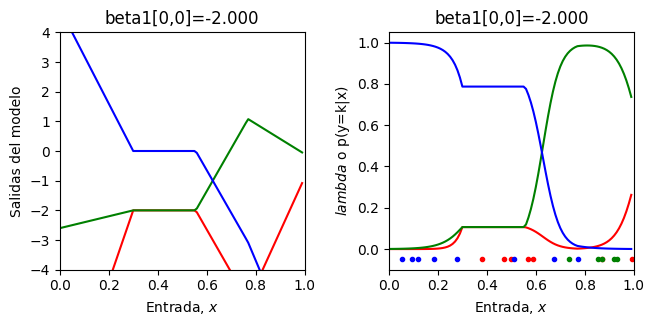

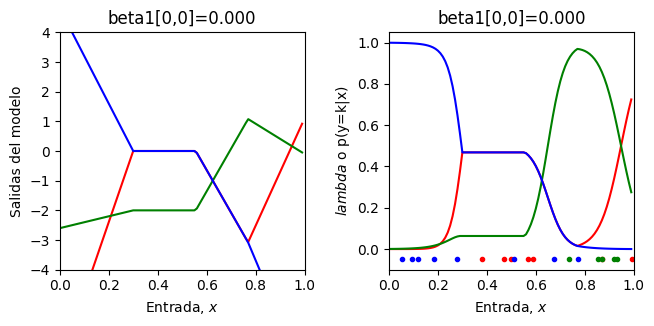

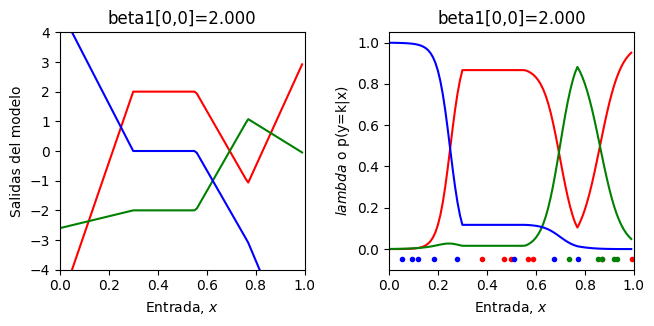

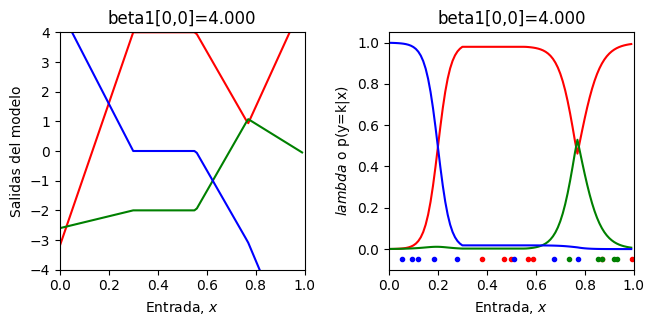

In [13]:
# Define un rango de valores para el parámetro
beta_1_vals = np.arange(-2,6.0,0.1)
# Crea arreglos para almacenar las likelihood y las likelihood logarítmicas negativas
likelihoods = np.zeros_like(beta_1_vals)
nlls = np.zeros_like(beta_1_vals)

# Inicializa los parámetros
beta_0, omega_0, beta_1, omega_1 = get_parameters()
for count in range(len(beta_1_vals)):
  # Asigna el valor del parámetro
  beta_1[0,0] = beta_1_vals[count]
  # Ejecuta la red con los nuevos parámetros
  model_out = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
  lambda_train = softmax(model_out)
  # Calcula y almacena los dos valores
  likelihoods[count] = compute_likelihood(y_train,lambda_train)
  nlls[count] = compute_negative_log_likelihood(y_train, lambda_train)
  # Dibuja el modelo cada 20 configuraciones del parámetro
  if count % 20 == 0:
    # Ejecuta el modelo para obtener y graficar sus valores
    model_out = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
    lambda_model = softmax(model_out)
    plot_multiclass_classification(x_model, model_out, lambda_model, x_train, y_train, title="beta1[0,0]=%3.3f"%(beta_1[0,0]))


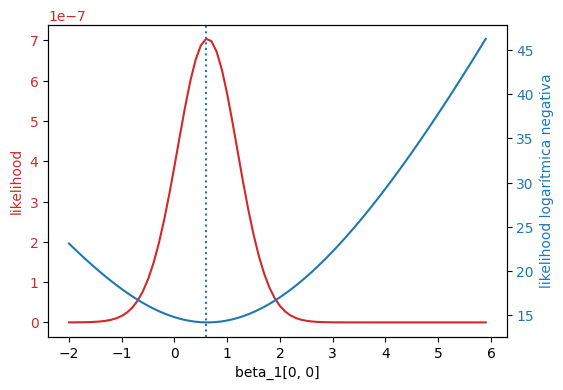

In [14]:
# Grafica la likelihood y la likelihood logarítmica negativa según el valor del desplazamiento beta1
fig, ax = plt.subplots()
fig.tight_layout(pad=5.0)
likelihood_color = 'tab:red'
nll_color = 'tab:blue'


ax.set_xlabel('beta_1[0, 0]')
ax.set_ylabel('likelihood', color = likelihood_color)
ax.plot(beta_1_vals, likelihoods, color = likelihood_color)
ax.tick_params(axis='y', labelcolor=likelihood_color)

ax1 = ax.twinx()
ax1.plot(beta_1_vals, nlls, color = nll_color)
ax1.set_ylabel('likelihood logarítmica negativa', color = nll_color)
ax1.tick_params(axis='y', labelcolor = nll_color)

plt.axvline(x = beta_1_vals[np.argmax(likelihoods)], linestyle='dotted')

plt.show()

Máxima likelihood = 0.000001, en beta_1=0.600
Mínima likelihood logarítmica negativa = 14.166574, en beta_1=0.600


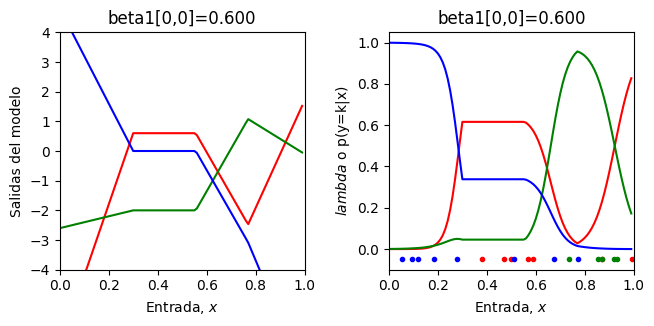

In [15]:
# El máximo de la likelihood debe estar en la misma posición que el mínimo de la likelihood logarítmica negativa
# Compruébalo:
print("Máxima likelihood = %f, en beta_1=%3.3f"%( (likelihoods[np.argmax(likelihoods)],beta_1_vals[np.argmax(likelihoods)])))
print("Mínima likelihood logarítmica negativa = %f, en beta_1=%3.3f"%( (nlls[np.argmin(nlls)],beta_1_vals[np.argmin(nlls)])))

# Grafica el mejor modelo
beta_1[0,0] = beta_1_vals[np.argmin(nlls)]
model_out = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
lambda_model = softmax(model_out)
plot_multiclass_classification(x_model, model_out, lambda_model, x_train, y_train, title="beta1[0,0]=%3.3f"%(beta_1[0,0]))


Ambas medidas dan la misma respuesta. Sin embargo, la likelihood es muy pequeña a menos que los parámetros sean casi correctos. Por eso, en la práctica se trabaja con la likelihood logarítmica negativa.<br><br>

Para ajustar el modelo neuronal completo, variaríamos los 16 parámetros de la red en $\boldsymbol\beta_{0},\boldsymbol\Omega_{0},\boldsymbol\beta_{1},\boldsymbol\Omega_{1}$ hasta encontrar la combinación con máxima likelihood o mínima likelihood logarítmica negativa.<br><br>

